In [31]:
import numpy as np
import cv2
from matplotlib import pyplot as TNKY



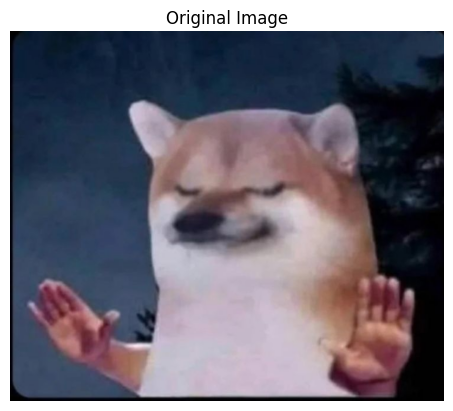

In [32]:
# 1.
# đọc ảnh
img = cv2.imread('hinh1.jpg')

# hiển thị ảnh (cv2 đọc BGR nên phải đảo sang RGB)
TNKY.imshow(img[:,:,::-1])
TNKY.title("Original Image")
TNKY.axis('off')
TNKY.show()

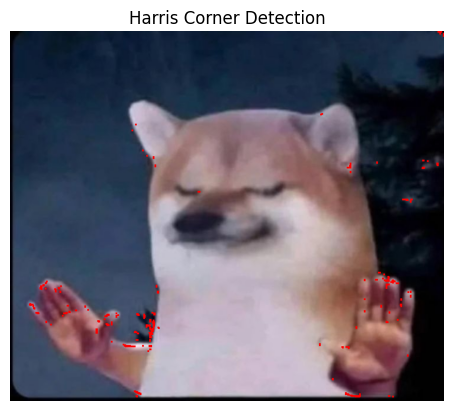

In [33]:
#2.

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

# Harris Corner
dst = cv2.cornerHarris(gray,2,3,0.04)

# dilate để làm rõ
dst = cv2.dilate(dst,None)

# đánh dấu góc
img_harris = img.copy()
img_harris[dst > 0.01 * dst.max()] = [0,0,255]

TNKY.imshow(img_harris[:,:,::-1])
TNKY.title("Harris Corner Detection")
TNKY.axis('off')
TNKY.show()

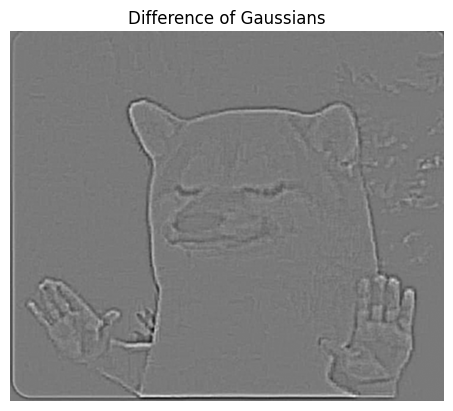

In [34]:
#3.
blur1 = cv2.GaussianBlur(gray,(5,5),1)
blur2 = cv2.GaussianBlur(gray,(9,9),2)

dog = blur1 - blur2

TNKY.imshow(dog,cmap='gray')
TNKY.title("Difference of Gaussians")
TNKY.axis('off')
TNKY.show()

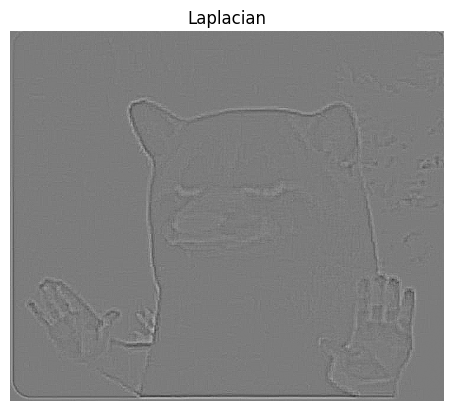

In [35]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

log = cv2.Laplacian(gray, cv2.CV_64F)

TNKY.imshow(log, cmap='gray')
TNKY.title("Laplacian")
TNKY.axis('off')
TNKY.show()

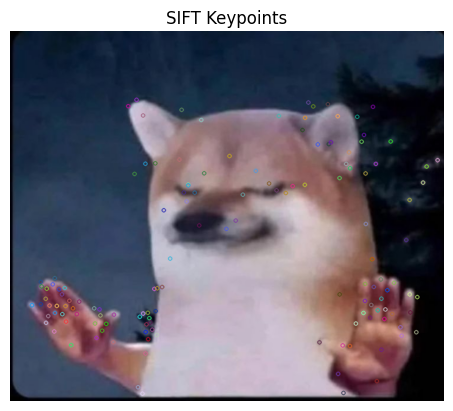

In [36]:
#5.
sift = cv2.SIFT_create()

kp, des = sift.detectAndCompute(gray,None)

img_sift = cv2.drawKeypoints(img,kp,None)

TNKY.imshow(img_sift[:,:,::-1])
TNKY.title("SIFT Keypoints")
TNKY.axis('off')
TNKY.show()

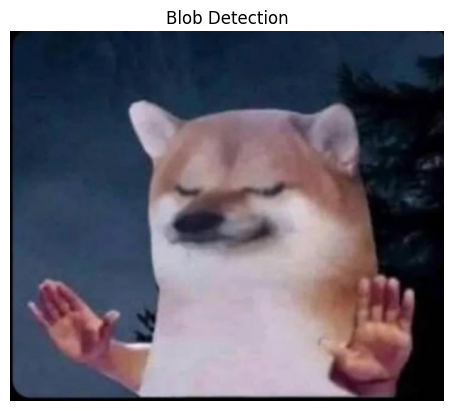

In [37]:
#6.
params = cv2.SimpleBlobDetector_Params()

params.filterByArea = True
params.minArea = 100

detector = cv2.SimpleBlobDetector_create(params)

keypoints = detector.detect(gray)

img_blob = cv2.drawKeypoints(img,keypoints,None,(0,0,255),
                             cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

TNKY.imshow(img_blob[:,:,::-1])
TNKY.title("Blob Detection")
TNKY.axis('off')
TNKY.show()

In [38]:
#7.
from sklearn.cluster import KMeans

sift = cv2.SIFT_create()
kp, des = sift.detectAndCompute(gray,None)

kmeans = KMeans(n_clusters=20)
kmeans.fit(des)

histogram = np.bincount(kmeans.labels_)
print(histogram)

[ 6  4  9 19  7  5  9  5  6  8  7  8  9 15 12  8  9  7 10  8]


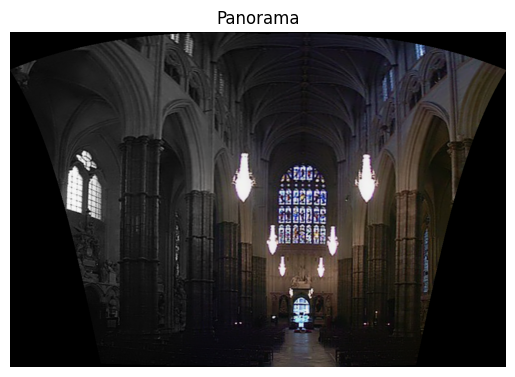

In [39]:
#8
img1 = cv2.imread("a1.png")
img2 = cv2.imread("a2.png")

stitcher = cv2.Stitcher_create()

status, pano = stitcher.stitch([img1,img2])

TNKY.imshow(pano[:,:,::-1])
TNKY.title("Panorama")
TNKY.axis('off')
TNKY.show()

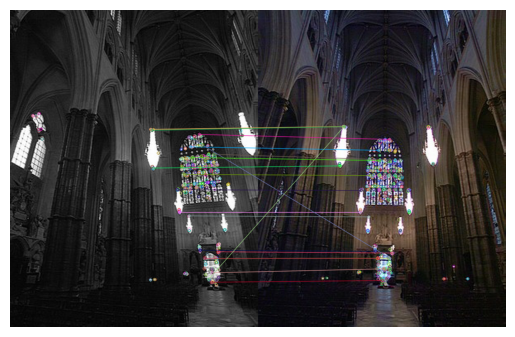

In [40]:
#9.
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(img1,None)
kp2, des2 = orb.detectAndCompute(img2,None)

bf = cv2.BFMatcher()

matches = bf.match(des1,des2)

matches = sorted(matches,key=lambda x:x.distance)

img_match = cv2.drawMatches(img1,kp1,img2,kp2,matches[:20],None)

TNKY.imshow(img_match[:,:,::-1])
TNKY.axis('off')
TNKY.show()

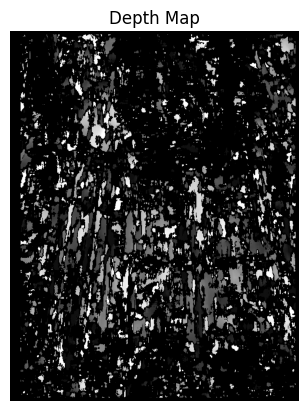

In [41]:
#10.
stereo = cv2.StereoBM_create(numDisparities=16, blockSize=15)

left = cv2.imread('a1.png',0)
right = cv2.imread('a2.png',0)

disparity = stereo.compute(left,right)

TNKY.imshow(disparity,cmap='gray')
TNKY.title("Depth Map")
TNKY.axis('off')
TNKY.show()

In [42]:
# tính histogram
hist1 = cv2.calcHist([img1],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])
hist2 = cv2.calcHist([img2],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])

# chuẩn hóa
hist1 = cv2.normalize(hist1,hist1).flatten()
hist2 = cv2.normalize(hist2,hist2).flatten()

# so sánh histogram
similarity = cv2.compareHist(hist1,hist2,cv2.HISTCMP_CORREL)

print("Similarity:", similarity)

Similarity: 0.9551615982497232


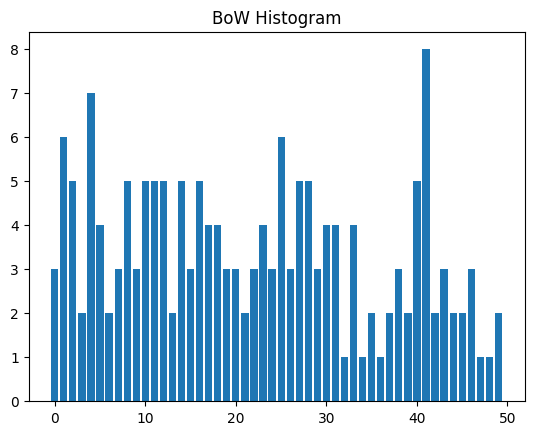

In [44]:
#12
sift = cv2.SIFT_create()
kp, des = sift.detectAndCompute(gray,None)

kmeans = KMeans(n_clusters=50)
kmeans.fit(des)

labels = kmeans.predict(des)

bow_hist = np.bincount(labels,minlength=50)

TNKY.bar(range(50),bow_hist)
TNKY.title("BoW Histogram")
TNKY.show()
